# Case study E2: Real-time Neural MPC

Real-time Neural MPC (Salzmann et al., RA-L 2023) puts a learned MLP into the dynamics of an MPC run
by acados. Its Table II times two ways of doing that as the network grows:

- **naive**: the network expanded into the CasADi model, which acados code-generates together with
  its sensitivities;
- **RTN-MPC**: PyTorch evaluates the network and its Jacobian at the previous solution after every
  solve, and acados sees only a first-order Taylor model whose coefficients are parameters.

The naive column is fast for small networks and collapses from width 128. RTN-MPC stays fast but
drops the exact model. Scaly generates the network's code in two places here:

- **inside acados**: the exact model's sensitivities (`expl_vde_forw`), swapped into acados' own build;
- **in place of PyTorch**: RTN-MPC's Taylor coefficients at the 10 shooting nodes, one `vmap`.

The Scaly cells below run without PyTorch or acados. The baseline cells need both
(`baseline/setup.sh` builds acados) and are off by default (`RUN_BASELINES`); the recorded results in
`results/` are shown instead. The write-up is `internal/notes/case_study_e2_report.html`.

In [1]:
import json
import os
import subprocess
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

HERE = Path.cwd()
sys.path[:0] = [str(HERE), str(HERE / "baseline"), str(HERE.parents[1] / "notebooks"), str(HERE.parent / "fatrop_chain")]

import plotstyle
import scaly as sc
from scaly.codegen import write_module

import scaly_impl
from kernel_bench import time_c, work_sizes

plotstyle.use()
RUN_BASELINES = False  # True reruns the acados grid and the kernel timings: about an hour, needs acados and torch
RESULTS = HERE / "results"

## The benchmark

Table II is a 1D double integrator, $x = (s, \dot s)$, $u = \ddot s$ with $|u| \le 10$, plus the
residual $f_D(x)$ of an untrained MLP with tanh activations, under acados SQP-RTI: $N = 10$ over 1 s,
ERK (RK4, one step), Gauss-Newton, full condensing HPIPM, tracking a sine on $s$. The loop is 50
control steps, and the paper reports $1/\text{mean}$ step time.

The authors zero the network's output layer so the untrained model does not change the dynamics.
With CasADi 3.8 that lets the expanded model drop the network entirely, and the naive column runs at
about 12 kHz whatever the network. Here the output weights are $10^{-6}\,\mathcal N(0,1)/\sqrt{w}$:
the dynamics stay nominal to about $10^{-6}$ and every column evaluates every layer.

A network in ml-casadi's layout, `MultiLayerPerceptron(2, width, 2, layers, "Tanh")`, with PyTorch's
default initialization, built here with NumPy:

In [2]:
def network(layers: int, width: int, out_scale: float = 1e-6, seed: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
  rng = np.random.default_rng(seed)
  sizes = [2] + [width] * layers
  params = []
  for fan_in, fan_out in zip(sizes[:-1], sizes[1:]):
    bound = 1 / np.sqrt(fan_in)
    params.append((rng.uniform(-bound, bound, (fan_out, fan_in)), rng.uniform(-bound, bound, fan_out)))
  params.append((out_scale * rng.standard_normal((2, width)) / np.sqrt(width), np.zeros(2)))
  return params


def mlp_np(params, x):
  h = x
  for W, b in params[:-1]:
    h = np.tanh(W @ h + b)
  W, b = params[-1]
  return W @ h + b


params = network(5, 128)
print(f"5 x 128: {sum(W.size + b.size for W, b in params):,} parameters")

5 x 128: 66,690 parameters


## The exact model inside acados

acados' ERK integrator calls `expl_vde_forw(x, Sx, Sp, u, p)` four times per shooting interval: the
model's value and its forward sensitivities. `scaly_impl.acados_functions` writes it as a Scaly
Function under acados' name, with the network's dense layers kept as loops and differentiated through
them. Checked here against central differences of the NumPy network:

In [3]:
fns = scaly_impl.acados_functions(params)
vde = fns["wr_expl_vde_forw"]
rng = np.random.default_rng(1)
x, u = np.array([0.4, -0.3]), np.array([0.7])
sx, sp = rng.standard_normal((2, 2)), rng.standard_normal(2)
f, sx_dot, sp_dot = (np.asarray(o) for o in vde(x, sx.T.reshape(-1), sp, u, np.zeros(0)))


def f_np(x, u):
  return np.array([x[1], u[0]]) + mlp_np(params, x)


eps = 1e-6
jx = np.stack([(f_np(x + eps * e, u) - f_np(x - eps * e, u)) / (2 * eps) for e in np.eye(2)], axis=1)
ju = ((f_np(x, u + eps) - f_np(x, u - eps)) / (2 * eps))
print("value error", np.abs(f - f_np(x, u)).max())
print("Sx_dot error", np.abs(sx_dot.reshape(2, 2).T - jx @ sx).max())
print("Sp_dot error", np.abs(sp_dot - (jx @ sp + ju)).max())

value error 0.0
Sx_dot error 3.966094119789432e-11
Sp_dot error 3.652156355116176e-11


Timed from C through the entry point acados calls, as `kernel_bench.py` does (the CasADi side of that
comparison needs acados' generated code, so it is read from `results/kernels.json` below):

In [4]:
def c_time(fn, inputs, outputs, casadi=True):
  work = Path(tempfile.mkdtemp(prefix="nb-neural-"))
  module = write_module(fn, work / "src", casadi=casadi)
  lib = work / "lib.so"
  flags = ["-O2", "-mcpu=native", "-fno-math-errno", *(["-Dcasadi_int=int"] if casadi else [])]
  subprocess.run(["cc", *flags, "-shared", "-fPIC", "-o", str(lib), str(work / "src" / module.source_name)], check=True)
  sizes = work_sizes(lib, fn.name) if casadi else (max(module.workspace_size, 1), 0, 4, 4)
  return time_c(lib, fn.name, inputs, outputs, sizes, work, repeats=300)[0]


for layers, width in [(2, 16), (5, 128)]:
  p = network(layers, width)
  t_vde = c_time(scaly_impl.acados_functions(p)["wr_expl_vde_forw"], [x, sx.T.reshape(-1), sp, u, np.zeros(0)], [2, 4, 2])
  t_taylor = c_time(scaly_impl.taylor_function(p), [rng.standard_normal(20)], [80], casadi=False)
  print(f"{layers} x {width}: expl_vde_forw {1e6 * t_vde:.2f} µs, Taylor coefficients at 10 nodes {1e6 * t_taylor:.1f} µs")

2 x 16: expl_vde_forw 0.19 µs, Taylor coefficients at 10 nodes 2.9 µs
5 x 128: expl_vde_forw 31.85 µs, Taylor coefficients at 10 nodes 325.5 µs


The Taylor function's first two layers in the generated C. Each is a register-blocked matrix-vector
product over a constant weight table, run once per node for the value and once more, two columns
wide, for the Jacobian. PyTorch instead multiplies each layer by all 10 nodes at once, which is why
it wins for wide networks (below).

In [5]:
work = Path(tempfile.mkdtemp(prefix="nb-neural-src-"))
module = write_module(scaly_impl.taylor_function(network(5, 128)), work)
lines = (work / module.source_name).read_text().splitlines()
start = next(i for i, line in enumerate(lines) if "for (long long ib_" in line) - 3
print("\n".join(line if len(line) <= 110 else line[:107] + "..." for line in lines[start : start + 34]))

  for (long long i_t6 = 0; i_t6 < 128; ++i_t6) {
    s0[i_t6] = 0.0;
  }
  for (long long ib_t6 = 0; ib_t6 < 32; ++ib_t6) {
    for (long long k_t6 = 0; k_t6 < 2; ++k_t6) {
      int64_t v0 = (ib_t6 * 4);
      s0[v0] = (s0[v0] + (k5[((v0 * 2) + k_t6)] * x[k_t6]));
      int64_t v1 = ((ib_t6 * 4) + 1);
      s0[v1] = (s0[v1] + (k5[((v1 * 2) + k_t6)] * x[k_t6]));
      int64_t v2 = ((ib_t6 * 4) + 2);
      s0[v2] = (s0[v2] + (k5[((v2 * 2) + k_t6)] * x[k_t6]));
      int64_t v3 = ((ib_t6 * 4) + 3);
      s0[v3] = (s0[v3] + (k5[((v3 * 2) + k_t6)] * x[k_t6]));
    }
  }
  for (long long i_t9 = 0; i_t9 < 128; ++i_t9) {
    s1[i_t9] = tanh((s0[i_t9] + k7[i_t9]));
  }
  for (long long i_t10 = 0; i_t10 < 128; ++i_t10) {
    s0[i_t10] = 0.0;
  }
  for (long long ib_t10 = 0; ib_t10 < 32; ++ib_t10) {
    for (long long k_t10 = 0; k_t10 < 128; ++k_t10) {
      int64_t v4 = (ib_t10 * 4);
      s0[v4] = (s0[v4] + (k4[((v4 * 128) + k_t10)] * s1[k_t10]));
      int64_t v5 = ((ib_t10 * 4) + 1);
      s

## The closed-loop grid

`compare.py` runs every network of Table II through four columns, each in three fresh processes: the
paper's naive and RTN-MPC, Scaly inside acados (the naive OCP with its model sources replaced), and
RTN-MPC with Scaly's Taylor function in place of PyTorch. The paper's i7 numbers are context only.

In [6]:
if RUN_BASELINES:
  acados = HERE / "baseline" / "third_party" / "acados"
  env = {**os.environ, "ACADOS_SOURCE_DIR": str(acados), "DYLD_LIBRARY_PATH": str(acados / "lib")}
  subprocess.run(["sh", str(HERE / "baseline" / "setup.sh")], check=True)
  uv = ["uv", "run", "--with", "torch", "--with", str(acados / "interfaces" / "acados_template")]
  subprocess.run([*uv, str(HERE / "compare.py"), "--out", str(RESULTS / "grid.json")], check=True, env=env)
  subprocess.run([*uv, str(HERE / "kernel_bench.py"), "--out", str(RESULTS / "kernels.json")], check=True, env=env)
grid = json.loads((RESULTS / "grid.json").read_text())
kernels = json.loads((RESULTS / "kernels.json").read_text())

SIZES = [(2, 16), (5, 16), (12, 32), (2, 128), (5, 128), (12, 512)]
PAPER = {(2, 16): (2228, 1096), (5, 16): (1139, 885), (12, 32): (168, 588), (2, 128): (116, 1071), (5, 128): (31, 784), (12, 512): (11, 507)}
COLUMNS = [("naive", "naive (CasADi)"), ("rtn", "RTN-MPC (PyTorch)"), ("dropin", "Scaly in acados"), ("taylor", "Scaly Taylor")]
print(f"{'network':>9} {'paper naive':>12} {'paper RTN':>10}" + "".join(f"{label:>20}" for _, label in COLUMNS))
for size in SIZES:
  row = [grid[f"{c}:{size[0]}x{size[1]}"]["hz_mean"] for c, _ in COLUMNS]
  print(f"{size[0]:>4} x {size[1]:<3} {PAPER[size][0]:>12} {PAPER[size][1]:>10}" + "".join(f"{hz:>17.0f} Hz" for hz in row))
for size in [(2, 128), (5, 128)]:
  r = grid[f"naive0:{size[0]}x{size[1]}"]
  print(f"{size[0]} x {size[1]} with the authors' zeroed output layer: naive {r['hz_mean']:.0f} Hz, linearization {1e6 * r['t_lin_median']:.0f} µs")

  network  paper naive  paper RTN      naive (CasADi)   RTN-MPC (PyTorch)     Scaly in acados        Scaly Taylor
   2 x 16          2228       1096             6974 Hz             3553 Hz            10274 Hz             6188 Hz
   5 x 16          1139        885             4582 Hz             3048 Hz             9364 Hz             4735 Hz
  12 x 32           168        588             1201 Hz             2398 Hz             1678 Hz             5022 Hz
   2 x 128          116       1071              513 Hz             3289 Hz             2249 Hz             2812 Hz
   5 x 128           31        784              134 Hz             2812 Hz              694 Hz             2103 Hz
  12 x 512           11        507                2 Hz              945 Hz                9 Hz               36 Hz
2 x 128 with the authors' zeroed output layer: naive 11915 Hz, linearization 5 µs
5 x 128 with the authors' zeroed output layer: naive 11984 Hz, linearization 5 µs


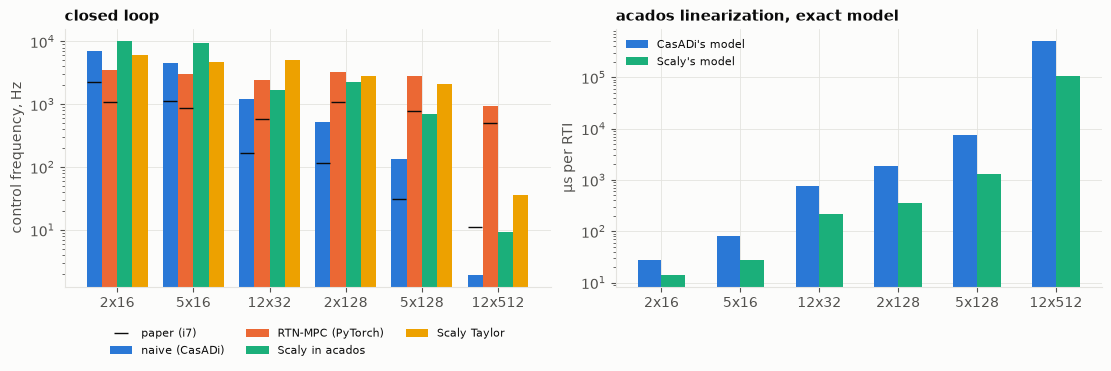

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
labels = [f"{l}x{w}" for l, w in SIZES]
xs = np.arange(len(SIZES))
for i, (c, label) in enumerate(COLUMNS):
  axes[0].bar(xs + (i - 1.5) * 0.2, [grid[f"{c}:{l}x{w}"]["hz_mean"] for l, w in SIZES], width=0.2, label=label)
axes[0].plot(xs - 0.3, [PAPER[s][0] for s in SIZES], "_", color=plotstyle.TEXT, markersize=10, label="paper (i7)")
axes[0].plot(xs - 0.1, [PAPER[s][1] for s in SIZES], "_", color=plotstyle.TEXT, markersize=10)
axes[0].set_yscale("log")
axes[0].set_xticks(xs, labels)
axes[0].set_ylabel("control frequency, Hz")
axes[0].set_title("closed loop")
axes[0].legend(fontsize=8, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
lin = np.array([[1e6 * grid[f"{c}:{l}x{w}"]["t_lin_median"] for l, w in SIZES] for c in ("naive", "dropin")])
axes[1].bar(xs - 0.15, lin[0], width=0.3, color=plotstyle.BLUE, label="CasADi's model")
axes[1].bar(xs + 0.15, lin[1], width=0.3, color=plotstyle.AQUA, label="Scaly's model")
axes[1].set_yscale("log")
axes[1].set_xticks(xs, labels)
axes[1].set_ylabel("µs per RTI")
axes[1].set_title("acados linearization, exact model")
axes[1].legend(fontsize=8)
plt.show()

## The two kernels alone

The closed-loop frequencies of small networks are mostly acados' Python interface. Timed alone
(`kernel_bench.py`): the sensitivity function acados calls, CasADi's against Scaly's, and the Taylor
coefficients at 10 nodes, PyTorch in float32 (what the paper runs) and float64 against Scaly.

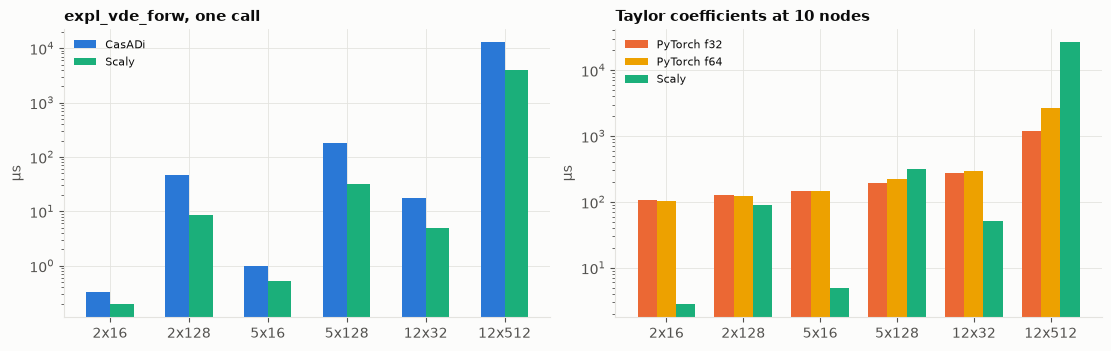

 2 x 16   vde CasADi/Scaly  1.7x   Taylor PyTorch f32/Scaly  38.13x
 2 x 128  vde CasADi/Scaly  5.4x   Taylor PyTorch f32/Scaly   1.39x
 5 x 16   vde CasADi/Scaly  1.9x   Taylor PyTorch f32/Scaly  29.45x
 5 x 128  vde CasADi/Scaly  5.7x   Taylor PyTorch f32/Scaly   0.61x
12 x 32   vde CasADi/Scaly  3.5x   Taylor PyTorch f32/Scaly   5.37x
12 x 512  vde CasADi/Scaly  3.3x   Taylor PyTorch f32/Scaly   0.05x


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
names = [f"{r['layers']}x{r['width']}" for r in kernels]
xk = np.arange(len(kernels))
axes[0].bar(xk - 0.15, [1e6 * r["casadi_vde_s"] for r in kernels], width=0.3, color=plotstyle.BLUE, label="CasADi")
axes[0].bar(xk + 0.15, [1e6 * r["scaly_vde_s"] for r in kernels], width=0.3, color=plotstyle.AQUA, label="Scaly")
axes[0].set_title("expl_vde_forw, one call")
for i, (label, key, color) in enumerate([("PyTorch f32", "torch32_taylor_s", plotstyle.ORANGE), ("PyTorch f64", "torch64_taylor_s", plotstyle.YELLOW), ("Scaly", "scaly_taylor_s", plotstyle.AQUA)]):
  axes[1].bar(xk + (i - 1) * 0.25, [1e6 * r[key] for r in kernels], width=0.25, color=color, label=label)
axes[1].set_title("Taylor coefficients at 10 nodes")
for ax in axes:
  ax.set_yscale("log")
  ax.set_xticks(xk, names)
  ax.set_ylabel("µs")
  ax.legend(fontsize=8)
plt.show()
for r in kernels:
  print(f"{r['layers']:>2} x {r['width']:<3}  vde CasADi/Scaly {r['casadi_vde_s'] / r['scaly_vde_s']:4.1f}x   Taylor PyTorch f32/Scaly {r['torch32_taylor_s'] / r['scaly_taylor_s']:6.2f}x")

## What it shows

- acados' generic path accepts Scaly's `casadi=True` output. The dense sensitivity matrix has to
  travel as a flat column-major vector, and `casadi_int` has to be defined as `int`.
- The exact model's sensitivities are 1.7 to 5.7x faster than CasADi's, and acados' linearization
  1.9 to 5.5x. That beats RTN-MPC's surrogate for width-16 networks, but not from width 32 up: the
  exact model evaluates the network 40 times per RTI with three tangents, the surrogate 10 times.
- As the surrogate's backend, Scaly is 29 to 38x faster than PyTorch for width 16 and 5x for 12 x 32,
  and loses from width 128: 0.6x at 5 x 128, 0.05x at 12 x 512, where PyTorch multiplies each layer by
  all nodes at once (`internal/todo.md`, CS-9).
- The network written as a model `Function` costs 2x inside the sensitivity function, because its
  derivative recomputes the forward pass (CS-10); `scaly_impl.py` writes it inline.